In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os
import pandas as pd

# =========================================================
# AffectNet dataset root
# =========================================================
affectnet_root = "/kaggle/input/datasets/mstjebashazida/affectnet/archive (3)"

# label mapping (keep this order fixed everywhere)
label_map_affect = {
    "anger": 0,
    "contempt": 1,
    "disgust": 2,
    "fear": 3,
    "happy": 4,
    "neutral": 5,
    "sad": 6,
    "surprise": 7
}

all_data = []

# =========================================================
# Read both Train and Test folders together
# =========================================================
for split_folder in ["Train", "Test"]:
    split_path = os.path.join(affectnet_root, split_folder)

    if not os.path.exists(split_path):
        continue

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        class_name_lower = class_name.lower()

        # handle possible case mismatch like Contempt / contempt / Anger / anger
        if class_name_lower not in label_map_affect:
            continue

        label = label_map_affect[class_name_lower]

        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            all_data.append([img_path, label])

# =========================================================
# Create full dataframe
# =========================================================
full_df_affect = pd.DataFrame(all_data, columns=["image_path", "label"])

print("Total images in full AffectNet:", len(full_df_affect))
print("\nClass distribution:")
print(full_df_affect["label"].value_counts().sort_index())

print("\nFirst 5 rows:")
display(full_df_affect.head())

Total images in full AffectNet: 30626

Class distribution:
label
0    3218
1    2871
2    2477
3    3176
4    5044
5    5126
6    4675
7    4039
Name: count, dtype: int64

First 5 rows:


,image_path,label
0,/kaggle/input/datasets/mstjebashazida/affectne...,7
1,/kaggle/input/datasets/mstjebashazida/affectne...,7
2,/kaggle/input/datasets/mstjebashazida/affectne...,7
3,/kaggle/input/datasets/mstjebashazida/affectne...,7
4,/kaggle/input/datasets/mstjebashazida/affectne...,7


In [2]:
from sklearn.model_selection import train_test_split

train_df_affect_70_30, test_df_affect_70_30 = train_test_split(
    full_df_affect,
    test_size=0.30,
    stratify=full_df_affect["label"],
    random_state=42
)

train_df_affect_70_30 = train_df_affect_70_30.reset_index(drop=True)
test_df_affect_70_30 = test_df_affect_70_30.reset_index(drop=True)

print("AffectNet 70:30 Train size:", len(train_df_affect_70_30))
print("AffectNet 70:30 Test size :", len(test_df_affect_70_30))

print("\nTrain class distribution:")
print(train_df_affect_70_30["label"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df_affect_70_30["label"].value_counts().sort_index())

AffectNet 70:30 Train size: 21438
AffectNet 70:30 Test size : 9188

Train class distribution:
label
0    2253
1    2010
2    1734
3    2223
4    3531
5    3588
6    3272
7    2827
Name: count, dtype: int64

Test class distribution:
label
0     965
1     861
2     743
3     953
4    1513
5    1538
6    1403
7    1212
Name: count, dtype: int64


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# =========================================================
# Generic AffectNet dataset class
# =========================================================
class AffectNetDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = int(self.df.loc[idx, "label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [4]:
from torchvision import transforms

# =========================================================
# CustomCNN transforms (same as your AffectNet CNN setup)
# =========================================================
cnn_train_transform_affect_70_30 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

cnn_test_transform_affect_70_30 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [5]:
# =========================================================
# CNN datasets
# =========================================================
train_dataset_cnn_affect_70_30 = AffectNetDataset(
    train_df_affect_70_30,
    transform=cnn_train_transform_affect_70_30
)

test_dataset_cnn_affect_70_30 = AffectNetDataset(
    test_df_affect_70_30,
    transform=cnn_test_transform_affect_70_30
)

# =========================================================
# CNN dataloaders
# =========================================================
train_loader_cnn_affect_70_30 = DataLoader(
    train_dataset_cnn_affect_70_30,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader_cnn_affect_70_30 = DataLoader(
    test_dataset_cnn_affect_70_30,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("CNN AffectNet 70:30 Train samples:", len(train_dataset_cnn_affect_70_30))
print("CNN AffectNet 70:30 Test samples :", len(test_dataset_cnn_affect_70_30))

CNN AffectNet 70:30 Train samples: 21438
CNN AffectNet 70:30 Test samples : 9188


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [7]:
import torch.nn as nn

# =========================================================
# Custom CNN for AffectNet (8 classes)
# =========================================================
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.fc(x)
        return x

cnn_model_affect_70_30 = CustomCNN(num_classes=8).to(device)
print(cnn_model_affect_70_30)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=18432, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6

In [8]:
import torch.optim as optim

criterion_cnn_affect_70_30 = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_cnn_affect_70_30 = optim.Adam(
    cnn_model_affect_70_30.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler_cnn_affect_70_30 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cnn_affect_70_30,
    T_max=80
)

In [10]:
from tqdm import tqdm
import copy
import os
import torch

# =========================================================
# Training settings
# =========================================================
num_epochs_cnn_affect_70_30 = 80
patience_cnn_affect_70_30 = 10

best_acc_cnn_affect_70_30 = 0.0
best_model_wts_cnn_affect_70_30 = copy.deepcopy(cnn_model_affect_70_30.state_dict())
epochs_no_improve_cnn_affect_70_30 = 0

train_acc_history_cnn_affect_70_30 = []
test_acc_history_cnn_affect_70_30 = []
train_loss_history_cnn_affect_70_30 = []
test_loss_history_cnn_affect_70_30 = []

# =========================================================
# Training loop
# =========================================================
for epoch in range(num_epochs_cnn_affect_70_30):
    print(f"\nEpoch {epoch+1}/{num_epochs_cnn_affect_70_30}")

    # =========================
    # TRAINING
    # =========================
    cnn_model_affect_70_30.train()
    running_loss = 0.0
    running_correct = 0
    total_train = 0

    for images, labels in tqdm(train_loader_cnn_affect_70_30):
        images = images.to(device)
        labels = labels.to(device)

        optimizer_cnn_affect_70_30.zero_grad()

        outputs = cnn_model_affect_70_30(images)
        loss = criterion_cnn_affect_70_30(outputs, labels)

        loss.backward()
        optimizer_cnn_affect_70_30.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = 100.0 * running_correct / total_train

    # =========================
    # VALIDATION / TEST
    # =========================
    cnn_model_affect_70_30.eval()
    running_loss = 0.0
    running_correct = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader_cnn_affect_70_30):
            images = images.to(device)
            labels = labels.to(device)

            outputs = cnn_model_affect_70_30(images)
            loss = criterion_cnn_affect_70_30(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_loss = running_loss / total_test
    test_acc = 100.0 * running_correct / total_test

    # scheduler step
    scheduler_cnn_affect_70_30.step()

    # store history
    train_loss_history_cnn_affect_70_30.append(train_loss)
    test_loss_history_cnn_affect_70_30.append(test_loss)
    train_acc_history_cnn_affect_70_30.append(train_acc)
    test_acc_history_cnn_affect_70_30.append(test_acc)

    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    # =========================
    # Save best model in memory
    # =========================
    if test_acc > best_acc_cnn_affect_70_30:
        best_acc_cnn_affect_70_30 = test_acc
        best_model_wts_cnn_affect_70_30 = copy.deepcopy(cnn_model_affect_70_30.state_dict())
        epochs_no_improve_cnn_affect_70_30 = 0
        print(f"Best model updated at epoch {epoch+1} with Test Acc = {test_acc:.2f}")
    else:
        epochs_no_improve_cnn_affect_70_30 += 1

    # =========================
    # Early stopping
    # =========================
    if epochs_no_improve_cnn_affect_70_30 >= patience_cnn_affect_70_30:
        print("Early stopping triggered")
        break

# =========================================================
# Load best weights back into model
# =========================================================
cnn_model_affect_70_30.load_state_dict(best_model_wts_cnn_affect_70_30)

# =========================================================
# Save best model to Kaggle working directory
# =========================================================
cnn_model_save_path_70_30 = "/kaggle/working/best_cnn_affectnet_70_30.pth"
torch.save(cnn_model_affect_70_30.state_dict(), cnn_model_save_path_70_30)

# =========================================================
# Verify save
# =========================================================
print("\nBest CNN AffectNet 70:30 Test Accuracy:", best_acc_cnn_affect_70_30)
print("Saved model:", cnn_model_save_path_70_30)
print("File exists after save? ->", os.path.exists(cnn_model_save_path_70_30))
print("Files currently in /kaggle/working:")
print(os.listdir("/kaggle/working"))


Epoch 1/80


100%|██████████| 288/288 [00:08<00:00, 34.31it/s]


Train Acc: 24.91 | Test Acc: 34.39
Train Loss: 1.8652 | Test Loss: 1.6881
Best model updated at epoch 1 with Test Acc = 34.39

Epoch 2/80


100%|██████████| 288/288 [00:08<00:00, 34.63it/s]


Train Acc: 27.98 | Test Acc: 32.85
Train Loss: 1.8165 | Test Loss: 1.6405

Epoch 3/80


...

Train Acc: 70.37 | Test Acc: 71.14
Train Loss: 1.1329 | Test Loss: 1.0977

Epoch 67/80


100%|██████████| 288/288 [00:08<00:00, 33.43it/s]


Train Acc: 70.19 | Test Acc: 71.17
Train Loss: 1.1310 | Test Loss: 1.0964

Epoch 68/80


100%|██████████| 288/288 [00:08<00:00, 34.83it/s]


Train Acc: 70.37 | Test Acc: 71.10
Train Loss: 1.1288 | Test Loss: 1.0972
Early stopping triggered

Best CNN AffectNet 70:30 Test Accuracy: 71.28863735306922
Saved model: /kaggle/working/best_cnn_affectnet_70_30.pth
File exists after save? -> True
Files currently in /kaggle/working:
['.virtual_documents', 'best_cnn_affectnet_70_30.pth']


In [11]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

# =========================================================
# Load best saved CNN model
# =========================================================
cnn_model_affect_70_30.load_state_dict(
    torch.load("/kaggle/working/best_cnn_affectnet_70_30.pth", map_location=device)
)
cnn_model_affect_70_30.to(device)
cnn_model_affect_70_30.eval()

cnn_probs_affect_70_30 = []
cnn_preds_affect_70_30 = []
y_true_affect_70_30 = []

# =========================================================
# Run inference on test set
# =========================================================
with torch.no_grad():
    for images, labels in test_loader_cnn_affect_70_30:
        images = images.to(device)
        labels = labels.to(device)

        outputs = cnn_model_affect_70_30(images)
        probs = F.softmax(outputs, dim=1)

        cnn_probs_affect_70_30.extend(probs.cpu().numpy())
        cnn_preds_affect_70_30.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_true_affect_70_30.extend(labels.cpu().numpy())

# convert to numpy arrays
cnn_probs_affect_70_30 = np.array(cnn_probs_affect_70_30)
cnn_preds_affect_70_30 = np.array(cnn_preds_affect_70_30)
y_true_affect_70_30 = np.array(y_true_affect_70_30)

# =========================================================
# Accuracy
# =========================================================
cnn_acc_affect_70_30 = accuracy_score(y_true_affect_70_30, cnn_preds_affect_70_30) * 100

print("CNN AffectNet 70:30 probabilities shape :", cnn_probs_affect_70_30.shape)
print("CNN AffectNet 70:30 predictions shape   :", cnn_preds_affect_70_30.shape)
print("CNN AffectNet 70:30 true labels shape   :", y_true_affect_70_30.shape)

print(f"\nCNN AffectNet 70:30 Accuracy from saved model: {cnn_acc_affect_70_30:.2f}%")

CNN AffectNet 70:30 probabilities shape : (9188, 8)
CNN AffectNet 70:30 predictions shape   : (9188,)
CNN AffectNet 70:30 true labels shape   : (9188,)

CNN AffectNet 70:30 Accuracy from saved model: 71.29%


In [12]:
from torchvision import transforms

# =========================================================
# ResNet50 transforms for AffectNet 70:30
# input size kept same as your previous AffectNet ResNet run
# =========================================================
resnet_train_transform_affect_70_30 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

resnet_test_transform_affect_70_30 = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [13]:
# =========================================================
# ResNet datasets
# =========================================================
train_dataset_resnet_affect_70_30 = AffectNetDataset(
    train_df_affect_70_30,
    transform=resnet_train_transform_affect_70_30
)

test_dataset_resnet_affect_70_30 = AffectNetDataset(
    test_df_affect_70_30,
    transform=resnet_test_transform_affect_70_30
)

# =========================================================
# ResNet dataloaders
# =========================================================
train_loader_resnet_affect_70_30 = DataLoader(
    train_dataset_resnet_affect_70_30,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader_resnet_affect_70_30 = DataLoader(
    test_dataset_resnet_affect_70_30,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("ResNet AffectNet 70:30 Train samples:", len(train_dataset_resnet_affect_70_30))
print("ResNet AffectNet 70:30 Test samples :", len(test_dataset_resnet_affect_70_30))

ResNet AffectNet 70:30 Train samples: 21438
ResNet AffectNet 70:30 Test samples : 9188


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# =========================================================
# ResNet50 Bottleneck block
# =========================================================
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, in_channels, out_channels, stride=1):
        super(Bottleneck, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.conv3 = nn.Conv2d(
            out_channels, out_channels * self.expansion,
            kernel_size=1, bias=False
        )
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels * self.expansion,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

# =========================================================
# ResNet50 Scratch
# =========================================================
class ResNet50Scratch(nn.Module):
    def __init__(self, num_classes=8):
        super(ResNet50Scratch, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            3, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(Bottleneck, 64, num_blocks=3, stride=1)
        self.layer2 = self._make_layer(Bottleneck, 128, num_blocks=4, stride=2)
        self.layer3 = self._make_layer(Bottleneck, 256, num_blocks=6, stride=2)
        self.layer4 = self._make_layer(Bottleneck, 512, num_blocks=3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512 * Bottleneck.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

# =========================================================
# Initialize model
# =========================================================
resnet_model_affect_70_30 = ResNet50Scratch(num_classes=8).to(device)
print(resnet_model_affect_70_30)

ResNet50Scratch(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05

In [15]:
import torch.optim as optim
import torch.nn as nn

criterion_resnet_affect_70_30 = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_resnet_affect_70_30 = optim.Adam(
    resnet_model_affect_70_30.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler_resnet_affect_70_30 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_resnet_affect_70_30,
    T_max=50
)

In [16]:
from tqdm import tqdm
import copy
import os
import torch

# =========================================================
# Training settings
# =========================================================
num_epochs_resnet_affect_70_30 = 50
patience_resnet_affect_70_30 = 10

best_acc_resnet_affect_70_30 = 0.0
best_model_wts_resnet_affect_70_30 = copy.deepcopy(resnet_model_affect_70_30.state_dict())
epochs_no_improve_resnet_affect_70_30 = 0

train_acc_history_resnet_affect_70_30 = []
test_acc_history_resnet_affect_70_30 = []
train_loss_history_resnet_affect_70_30 = []
test_loss_history_resnet_affect_70_30 = []

# =========================================================
# Training loop
# =========================================================
for epoch in range(num_epochs_resnet_affect_70_30):
    print(f"\nEpoch {epoch+1}/{num_epochs_resnet_affect_70_30}")

    # =========================
    # TRAINING
    # =========================
    resnet_model_affect_70_30.train()
    running_loss = 0.0
    running_correct = 0
    total_train = 0

    for images, labels in tqdm(train_loader_resnet_affect_70_30):
        images = images.to(device)
        labels = labels.to(device)

        optimizer_resnet_affect_70_30.zero_grad()

        outputs = resnet_model_affect_70_30(images)
        loss = criterion_resnet_affect_70_30(outputs, labels)

        loss.backward()
        optimizer_resnet_affect_70_30.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = 100.0 * running_correct / total_train

    # =========================
    # VALIDATION / TEST
    # =========================
    resnet_model_affect_70_30.eval()
    running_loss = 0.0
    running_correct = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader_resnet_affect_70_30):
            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model_affect_70_30(images)
            loss = criterion_resnet_affect_70_30(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_loss = running_loss / total_test
    test_acc = 100.0 * running_correct / total_test

    scheduler_resnet_affect_70_30.step()

    train_loss_history_resnet_affect_70_30.append(train_loss)
    test_loss_history_resnet_affect_70_30.append(test_loss)
    train_acc_history_resnet_affect_70_30.append(train_acc)
    test_acc_history_resnet_affect_70_30.append(test_acc)

    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    # =========================
    # Save best model in memory
    # =========================
    if test_acc > best_acc_resnet_affect_70_30:
        best_acc_resnet_affect_70_30 = test_acc
        best_model_wts_resnet_affect_70_30 = copy.deepcopy(resnet_model_affect_70_30.state_dict())
        epochs_no_improve_resnet_affect_70_30 = 0
        print(f"Best model updated at epoch {epoch+1} with Test Acc = {test_acc:.2f}")
    else:
        epochs_no_improve_resnet_affect_70_30 += 1

    # =========================
    # Early stopping
    # =========================
    if epochs_no_improve_resnet_affect_70_30 >= patience_resnet_affect_70_30:
        print("Early stopping triggered")
        break

# =========================================================
# Load best weights back into model
# =========================================================
resnet_model_affect_70_30.load_state_dict(best_model_wts_resnet_affect_70_30)

# =========================================================
# Save best model to Kaggle working directory
# =========================================================
resnet_model_save_path_70_30 = "/kaggle/working/best_resnet50_affectnet_70_30.pth"
torch.save(resnet_model_affect_70_30.state_dict(), resnet_model_save_path_70_30)

# =========================================================
# Verify save
# =========================================================
print("\nBest ResNet50 AffectNet 70:30 Test Accuracy:", best_acc_resnet_affect_70_30)
print("Saved model:", resnet_model_save_path_70_30)
print("File exists after save? ->", os.path.exists(resnet_model_save_path_70_30))
print("Files currently in /kaggle/working:")
print(os.listdir("/kaggle/working"))


Epoch 1/50


100%|██████████| 288/288 [00:08<00:00, 32.89it/s]


Train Acc: 22.98 | Test Acc: 33.91
Train Loss: 2.0560 | Test Loss: 1.6996
Best model updated at epoch 1 with Test Acc = 33.91

Epoch 2/50


100%|██████████| 288/288 [00:08<00:00, 33.76it/s]


Train Acc: 34.31 | Test Acc: 42.93
Train Loss: 1.7451 | Test Loss: 1.5834
Best model updated at epoch 2 with Test Acc = 42.93

Epoch 3/50


...

Train Acc: 80.47 | Test Acc: 70.46
Train Loss: 0.8906 | Test Loss: 1.1386

Epoch 49/50


100%|██████████| 288/288 [00:08<00:00, 33.69it/s]


Train Acc: 79.92 | Test Acc: 70.25
Train Loss: 0.8938 | Test Loss: 1.1430

Epoch 50/50


100%|██████████| 288/288 [00:08<00:00, 33.91it/s]


Train Acc: 80.12 | Test Acc: 70.24
Train Loss: 0.8906 | Test Loss: 1.1392

Best ResNet50 AffectNet 70:30 Test Accuracy: 70.76621680452764
Saved model: /kaggle/working/best_resnet50_affectnet_70_30.pth
File exists after save? -> True
Files currently in /kaggle/working:
['best_resnet50_affectnet_70_30.pth', '.virtual_documents', 'best_cnn_affectnet_70_30.pth']


In [17]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

# =========================================================
# Load best saved ResNet50 model
# =========================================================
resnet_model_affect_70_30.load_state_dict(
    torch.load("/kaggle/working/best_resnet50_affectnet_70_30.pth", map_location=device)
)
resnet_model_affect_70_30.to(device)
resnet_model_affect_70_30.eval()

resnet_probs_affect_70_30 = []
resnet_preds_affect_70_30 = []
y_true_affect_70_30_resnet = []

# =========================================================
# Run inference on test set
# =========================================================
with torch.no_grad():
    for images, labels in test_loader_resnet_affect_70_30:
        images = images.to(device)
        labels = labels.to(device)

        outputs = resnet_model_affect_70_30(images)
        probs = F.softmax(outputs, dim=1)

        resnet_probs_affect_70_30.extend(probs.cpu().numpy())
        resnet_preds_affect_70_30.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_true_affect_70_30_resnet.extend(labels.cpu().numpy())

# convert to numpy arrays
resnet_probs_affect_70_30 = np.array(resnet_probs_affect_70_30)
resnet_preds_affect_70_30 = np.array(resnet_preds_affect_70_30)
y_true_affect_70_30_resnet = np.array(y_true_affect_70_30_resnet)

# =========================================================
# Accuracy
# =========================================================
resnet_acc_affect_70_30 = accuracy_score(
    y_true_affect_70_30_resnet,
    resnet_preds_affect_70_30
) * 100

print("ResNet50 AffectNet 70:30 probabilities shape :", resnet_probs_affect_70_30.shape)
print("ResNet50 AffectNet 70:30 predictions shape   :", resnet_preds_affect_70_30.shape)
print("AffectNet 70:30 true labels shape            :", y_true_affect_70_30_resnet.shape)

print(f"\nResNet50 AffectNet 70:30 Accuracy from saved model: {resnet_acc_affect_70_30:.2f}%")

ResNet50 AffectNet 70:30 probabilities shape : (9188, 8)
ResNet50 AffectNet 70:30 predictions shape   : (9188,)
AffectNet 70:30 true labels shape            : (9188,)

ResNet50 AffectNet 70:30 Accuracy from saved model: 70.77%


In [18]:
from torchvision import transforms

# =========================================================
# Improved EfficientNet transforms for AffectNet 70:30
# =========================================================
eff_train_transform_affect_70_30 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eff_test_transform_affect_70_30 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [19]:
# =========================================================
# EfficientNet datasets
# =========================================================
train_dataset_eff_affect_70_30 = AffectNetDataset(
    train_df_affect_70_30,
    transform=eff_train_transform_affect_70_30
)

test_dataset_eff_affect_70_30 = AffectNetDataset(
    test_df_affect_70_30,
    transform=eff_test_transform_affect_70_30
)

# =========================================================
# EfficientNet dataloaders
# =========================================================
train_loader_eff_affect_70_30 = DataLoader(
    train_dataset_eff_affect_70_30,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_loader_eff_affect_70_30 = DataLoader(
    test_dataset_eff_affect_70_30,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("EfficientNet AffectNet 70:30 Train samples:", len(train_dataset_eff_affect_70_30))
print("EfficientNet AffectNet 70:30 Test samples :", len(test_dataset_eff_affect_70_30))

EfficientNet AffectNet 70:30 Train samples: 21438
EfficientNet AffectNet 70:30 Test samples : 9188


In [20]:
import torch
import torch.nn as nn
from torchvision import models

# =========================================================
# Improved EfficientNet-B3 for AffectNet 70:30
# =========================================================
class ImprovedEfficientNetAffect(nn.Module):
    def __init__(self, num_classes=8):
        super(ImprovedEfficientNetAffect, self).__init__()

        # load EfficientNet-B3 backbone
        self.backbone = models.efficientnet_b3(weights=None)

        # replace classifier
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# =========================================================
# Initialize model
# =========================================================
efficientnet_model_affect_70_30 = ImprovedEfficientNetAffect(num_classes=8).to(device)
print(efficientnet_model_affect_70_30)

ImprovedEfficientNetAffect(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
    

In [21]:
import torch.optim as optim
import torch.nn as nn

criterion_eff_affect_70_30 = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_eff_affect_70_30 = optim.Adam(
    efficientnet_model_affect_70_30.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

scheduler_eff_affect_70_30 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_eff_affect_70_30,
    T_max=60
)

In [22]:
from tqdm import tqdm
import copy
import os
import torch

# =========================================================
# Training settings
# =========================================================
num_epochs_eff_affect_70_30 = 60
patience_eff_affect_70_30 = 8

best_acc_eff_affect_70_30 = 0.0
best_model_wts_eff_affect_70_30 = copy.deepcopy(efficientnet_model_affect_70_30.state_dict())
epochs_no_improve_eff_affect_70_30 = 0

train_acc_history_eff_affect_70_30 = []
test_acc_history_eff_affect_70_30 = []
train_loss_history_eff_affect_70_30 = []
test_loss_history_eff_affect_70_30 = []

# =========================================================
# Training loop
# =========================================================
for epoch in range(num_epochs_eff_affect_70_30):
    print(f"\nEpoch {epoch+1}/{num_epochs_eff_affect_70_30}")

    # =========================
    # TRAIN
    # =========================
    efficientnet_model_affect_70_30.train()
    running_loss = 0.0
    running_correct = 0
    total_train = 0

    for images, labels in tqdm(train_loader_eff_affect_70_30):
        images = images.to(device)
        labels = labels.to(device)

        optimizer_eff_affect_70_30.zero_grad()

        outputs = efficientnet_model_affect_70_30(images)
        loss = criterion_eff_affect_70_30(outputs, labels)

        loss.backward()
        optimizer_eff_affect_70_30.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = 100.0 * running_correct / total_train

    # =========================
    # TEST / VALIDATION
    # =========================
    efficientnet_model_affect_70_30.eval()
    running_loss = 0.0
    running_correct = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader_eff_affect_70_30):
            images = images.to(device)
            labels = labels.to(device)

            outputs = efficientnet_model_affect_70_30(images)
            loss = criterion_eff_affect_70_30(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total_test += labels.size(0)

    test_loss = running_loss / total_test
    test_acc = 100.0 * running_correct / total_test

    scheduler_eff_affect_70_30.step()

    train_loss_history_eff_affect_70_30.append(train_loss)
    test_loss_history_eff_affect_70_30.append(test_loss)
    train_acc_history_eff_affect_70_30.append(train_acc)
    test_acc_history_eff_affect_70_30.append(test_acc)

    print(f"Train Acc: {train_acc:.2f} | Test Acc: {test_acc:.2f}")
    print(f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    # =========================
    # Save best model in memory
    # =========================
    if test_acc > best_acc_eff_affect_70_30:
        best_acc_eff_affect_70_30 = test_acc
        best_model_wts_eff_affect_70_30 = copy.deepcopy(efficientnet_model_affect_70_30.state_dict())
        epochs_no_improve_eff_affect_70_30 = 0
        print(f"Best model updated at epoch {epoch+1} with Test Acc = {test_acc:.2f}")
    else:
        epochs_no_improve_eff_affect_70_30 += 1

    # =========================
    # Early stopping
    # =========================
    if epochs_no_improve_eff_affect_70_30 >= patience_eff_affect_70_30:
        print("Early stopping triggered")
        break

# =========================================================
# Load best weights back
# =========================================================
efficientnet_model_affect_70_30.load_state_dict(best_model_wts_eff_affect_70_30)

# =========================================================
# Save best model
# =========================================================
eff_model_save_path_70_30 = "/kaggle/working/best_efficientnet_affectnet_70_30.pth"
torch.save(efficientnet_model_affect_70_30.state_dict(), eff_model_save_path_70_30)

# =========================================================
# Verify save
# =========================================================
print("\nBest Improved EfficientNet AffectNet 70:30 Test Accuracy:", best_acc_eff_affect_70_30)
print("Saved model:", eff_model_save_path_70_30)
print("File exists after save? ->", os.path.exists(eff_model_save_path_70_30))
print("Files currently in /kaggle/working:")
print(os.listdir("/kaggle/working"))


Epoch 1/60


100%|██████████| 288/288 [00:25<00:00, 11.11it/s]


Train Acc: 16.64 | Test Acc: 19.39
Train Loss: 2.0627 | Test Loss: 2.0219
Best model updated at epoch 1 with Test Acc = 19.39

Epoch 2/60


100%|██████████| 288/288 [00:25<00:00, 11.28it/s]


Train Acc: 26.89 | Test Acc: 32.32
Train Loss: 1.8267 | Test Loss: 1.6876
Best model updated at epoch 2 with Test Acc = 32.32

Epoch 3/60


...

Train Acc: 75.66 | Test Acc: 72.26
Train Loss: 0.9935 | Test Loss: 1.0742

Epoch 43/60


100%|██████████| 288/288 [00:25<00:00, 11.25it/s]


Train Acc: 75.68 | Test Acc: 72.08
Train Loss: 0.9883 | Test Loss: 1.0770

Epoch 44/60


100%|██████████| 288/288 [00:25<00:00, 11.24it/s]

Train Acc: 75.66 | Test Acc: 72.04
Train Loss: 0.9861 | Test Loss: 1.0728
Early stopping triggered

Best Improved EfficientNet AffectNet 70:30 Test Accuracy: 72.26817588158468
Saved model: /kaggle/working/best_efficientnet_affectnet_70_30.pth
File exists after save? -> True
Files currently in /kaggle/working:
['best_resnet50_affectnet_70_30.pth', '.virtual_documents', 'best_efficientnet_affectnet_70_30.pth', 'best_cnn_affectnet_70_30.pth']


In [23]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score

# =========================================================
# Load best saved Improved EfficientNet model
# =========================================================
efficientnet_model_affect_70_30.load_state_dict(
    torch.load("/kaggle/working/best_efficientnet_affectnet_70_30.pth", map_location=device)
)
efficientnet_model_affect_70_30.to(device)
efficientnet_model_affect_70_30.eval()

eff_probs_affect_70_30 = []
eff_preds_affect_70_30 = []
y_true_affect_70_30_eff = []

# =========================================================
# Run inference on test set
# =========================================================
with torch.no_grad():
    for images, labels in test_loader_eff_affect_70_30:
        images = images.to(device)
        labels = labels.to(device)

        outputs = efficientnet_model_affect_70_30(images)
        probs = F.softmax(outputs, dim=1)

        eff_probs_affect_70_30.extend(probs.cpu().numpy())
        eff_preds_affect_70_30.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_true_affect_70_30_eff.extend(labels.cpu().numpy())

# convert to numpy arrays
eff_probs_affect_70_30 = np.array(eff_probs_affect_70_30)
eff_preds_affect_70_30 = np.array(eff_preds_affect_70_30)
y_true_affect_70_30_eff = np.array(y_true_affect_70_30_eff)

# =========================================================
# Accuracy
# =========================================================
eff_acc_affect_70_30 = accuracy_score(
    y_true_affect_70_30_eff,
    eff_preds_affect_70_30
) * 100

print("Improved EfficientNet AffectNet 70:30 probabilities shape :", eff_probs_affect_70_30.shape)
print("Improved EfficientNet AffectNet 70:30 predictions shape   :", eff_preds_affect_70_30.shape)
print("AffectNet 70:30 true labels shape                         :", y_true_affect_70_30_eff.shape)

print(f"\nImproved EfficientNet AffectNet 70:30 Accuracy from saved model: {eff_acc_affect_70_30:.2f}%")

Improved EfficientNet AffectNet 70:30 probabilities shape : (9188, 8)
Improved EfficientNet AffectNet 70:30 predictions shape   : (9188,)
AffectNet 70:30 true labels shape                         : (9188,)

Improved EfficientNet AffectNet 70:30 Accuracy from saved model: 72.27%


In [25]:
import numpy as np
from sklearn.metrics import accuracy_score

# =========================================================
# Convert probability vector to DST mass
# =========================================================
def probs_to_mass(prob_vector, uncertainty=0.05):
    """
    prob_vector shape: (num_classes,)
    returns mass vector of shape (num_classes + 1,)
    last index = uncertainty mass
    """
    prob_vector = np.array(prob_vector, dtype=np.float64)
    prob_vector = prob_vector / prob_vector.sum()

    mass = np.zeros(len(prob_vector) + 1, dtype=np.float64)
    mass[:-1] = prob_vector * (1 - uncertainty)
    mass[-1] = uncertainty
    return mass

# =========================================================
# Dempster combination of two mass functions
# =========================================================
def dst_combine_two(m1, m2):
    n = len(m1) - 1  # number of classes
    combined = np.zeros(n + 1, dtype=np.float64)

    K = 0.0  # conflict

    # singleton-singleton combinations
    for i in range(n):
        for j in range(n):
            if i == j:
                combined[i] += m1[i] * m2[j]
            else:
                K += m1[i] * m2[j]

    # singleton with uncertainty
    for i in range(n):
        combined[i] += m1[i] * m2[-1] + m1[-1] * m2[i]

    # uncertainty with uncertainty
    combined[-1] = m1[-1] * m2[-1]

    # normalize
    if K < 1.0:
        combined = combined / (1.0 - K)

    return combined

# =========================================================
# Combine three mass functions
# =========================================================
def dst_combine_three(m1, m2, m3):
    temp = dst_combine_two(m1, m2)
    final = dst_combine_two(temp, m3)
    return final

In [26]:
# =========================================================
# Use one common y_true for fusion
# all 3 test sets are based on the same 70:30 split
# =========================================================
y_true_fusion_affect_70_30 = y_true_affect_70_30.copy()

# storage
cnn_resnet_preds_70_30 = []
cnn_eff_preds_70_30 = []
resnet_eff_preds_70_30 = []
cnn_resnet_eff_preds_70_30 = []

# =========================================================
# Loop through every test sample
# =========================================================
for i in range(len(y_true_fusion_affect_70_30)):
    # masses from each model
    m_cnn = probs_to_mass(cnn_probs_affect_70_30[i])
    m_resnet = probs_to_mass(resnet_probs_affect_70_30[i])
    m_eff = probs_to_mass(eff_probs_affect_70_30[i])

    # -------------------------
    # CNN + ResNet50
    # -------------------------
    m_cnn_resnet = dst_combine_two(m_cnn, m_resnet)
    pred_cnn_resnet = np.argmax(m_cnn_resnet[:-1])
    cnn_resnet_preds_70_30.append(pred_cnn_resnet)

    # -------------------------
    # CNN + Improved EfficientNet
    # -------------------------
    m_cnn_eff = dst_combine_two(m_cnn, m_eff)
    pred_cnn_eff = np.argmax(m_cnn_eff[:-1])
    cnn_eff_preds_70_30.append(pred_cnn_eff)

    # -------------------------
    # ResNet50 + Improved EfficientNet
    # -------------------------
    m_resnet_eff = dst_combine_two(m_resnet, m_eff)
    pred_resnet_eff = np.argmax(m_resnet_eff[:-1])
    resnet_eff_preds_70_30.append(pred_resnet_eff)

    # -------------------------
    # CNN + ResNet50 + Improved EfficientNet
    # -------------------------
    m_all = dst_combine_three(m_cnn, m_resnet, m_eff)
    pred_all = np.argmax(m_all[:-1])
    cnn_resnet_eff_preds_70_30.append(pred_all)

# convert to numpy arrays
cnn_resnet_preds_70_30 = np.array(cnn_resnet_preds_70_30)
cnn_eff_preds_70_30 = np.array(cnn_eff_preds_70_30)
resnet_eff_preds_70_30 = np.array(resnet_eff_preds_70_30)
cnn_resnet_eff_preds_70_30 = np.array(cnn_resnet_eff_preds_70_30)

# =========================================================
# Compute fusion accuracies
# =========================================================
cnn_resnet_acc_70_30 = accuracy_score(y_true_fusion_affect_70_30, cnn_resnet_preds_70_30) * 100
cnn_eff_acc_70_30 = accuracy_score(y_true_fusion_affect_70_30, cnn_eff_preds_70_30) * 100
resnet_eff_acc_70_30 = accuracy_score(y_true_fusion_affect_70_30, resnet_eff_preds_70_30) * 100
cnn_resnet_eff_acc_70_30 = accuracy_score(y_true_fusion_affect_70_30, cnn_resnet_eff_preds_70_30) * 100

print(f"CNN + ResNet50 DST Accuracy: {cnn_resnet_acc_70_30:.2f}%")
print(f"CNN + Improved EfficientNet DST Accuracy: {cnn_eff_acc_70_30:.2f}%")
print(f"ResNet50 + Improved EfficientNet DST Accuracy: {resnet_eff_acc_70_30:.2f}%")
print(f"CNN + ResNet50 + Improved EfficientNet DST Accuracy: {cnn_resnet_eff_acc_70_30:.2f}%")

CNN + ResNet50 DST Accuracy: 72.88%
CNN + Improved EfficientNet DST Accuracy: 73.14%
ResNet50 + Improved EfficientNet DST Accuracy: 73.23%
CNN + ResNet50 + Improved EfficientNet DST Accuracy: 73.91%


In [27]:
import pandas as pd

dst_results_affect_70_30 = pd.DataFrame({
    "Fusion Pair": [
        "CustomCNN + Improved EfficientNet",
        "CustomCNN + ResNet50 + Improved EfficientNet",
        "ResNet50 + Improved EfficientNet",
        "CustomCNN + ResNet50"
    ],
    "DST Accuracy (%)": [
        cnn_eff_acc_70_30,
        cnn_resnet_eff_acc_70_30,
        resnet_eff_acc_70_30,
        cnn_resnet_acc_70_30
    ]
}).sort_values(by="DST Accuracy (%)", ascending=False).reset_index(drop=True)

print("DST Fusion Results (AffectNet 70:30):")
display(dst_results_affect_70_30)

DST Fusion Results (AffectNet 70:30):


,Fusion Pair,DST Accuracy (%)
0,CustomCNN + ResNet50 + Improved EfficientNet,73.911624
1,ResNet50 + Improved EfficientNet,73.225947
2,CustomCNN + Improved EfficientNet,73.138877
3,CustomCNN + ResNet50,72.877667


In [28]:
final_results_affect_70_30 = pd.DataFrame({
    "Model / Fusion": [
        "CustomCNN",
        "ResNet50",
        "Improved EfficientNet",
        "CustomCNN + ResNet50",
        "CustomCNN + Improved EfficientNet",
        "ResNet50 + Improved EfficientNet",
        "CustomCNN + ResNet50 + Improved EfficientNet"
    ],
    "Accuracy (%)": [
        cnn_acc_affect_70_30,
        resnet_acc_affect_70_30,
        eff_acc_affect_70_30,
        cnn_resnet_acc_70_30,
        cnn_eff_acc_70_30,
        resnet_eff_acc_70_30,
        cnn_resnet_eff_acc_70_30
    ]
}).sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

print("Final AffectNet 70:30 Comparison Results:")
display(final_results_affect_70_30)

Final AffectNet 70:30 Comparison Results:


,Model / Fusion,Accuracy (%)
0,CustomCNN + ResNet50 + Improved EfficientNet,73.911624
1,ResNet50 + Improved EfficientNet,73.225947
2,CustomCNN + Improved EfficientNet,73.138877
3,CustomCNN + ResNet50,72.877667
4,Improved EfficientNet,72.268176
5,CustomCNN,71.288637
6,ResNet50,70.766217


In [29]:
import pandas as pd

report_results_affect_70_30 = pd.DataFrame({
    "Model / Fusion": [
        "CustomCNN",
        "ResNet50",
        "Improved EfficientNet",
        "CustomCNN + ResNet50",
        "CustomCNN + Improved EfficientNet",
        "ResNet50 + Improved EfficientNet",
        "CustomCNN + ResNet50 + Improved EfficientNet"
    ],
    "Accuracy (%)": [
        cnn_acc_affect_70_30,
        resnet_acc_affect_70_30,
        eff_acc_affect_70_30,
        cnn_resnet_acc_70_30,
        cnn_eff_acc_70_30,
        resnet_eff_acc_70_30,
        cnn_resnet_eff_acc_70_30
    ]
}).sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

print("Final AffectNet 70:30 Comparison Results:")
display(report_results_affect_70_30)

Final AffectNet 70:30 Comparison Results:


,Model / Fusion,Accuracy (%)
0,CustomCNN + ResNet50 + Improved EfficientNet,73.911624
1,ResNet50 + Improved EfficientNet,73.225947
2,CustomCNN + Improved EfficientNet,73.138877
3,CustomCNN + ResNet50,72.877667
4,Improved EfficientNet,72.268176
5,CustomCNN,71.288637
6,ResNet50,70.766217


In [31]:
class_names_affect = [
    "Surprise",
    "Fear",
    "Disgust",
    "Happy",
    "Sad",
    "Anger",
    "Neutral",
    "Contempt"
]

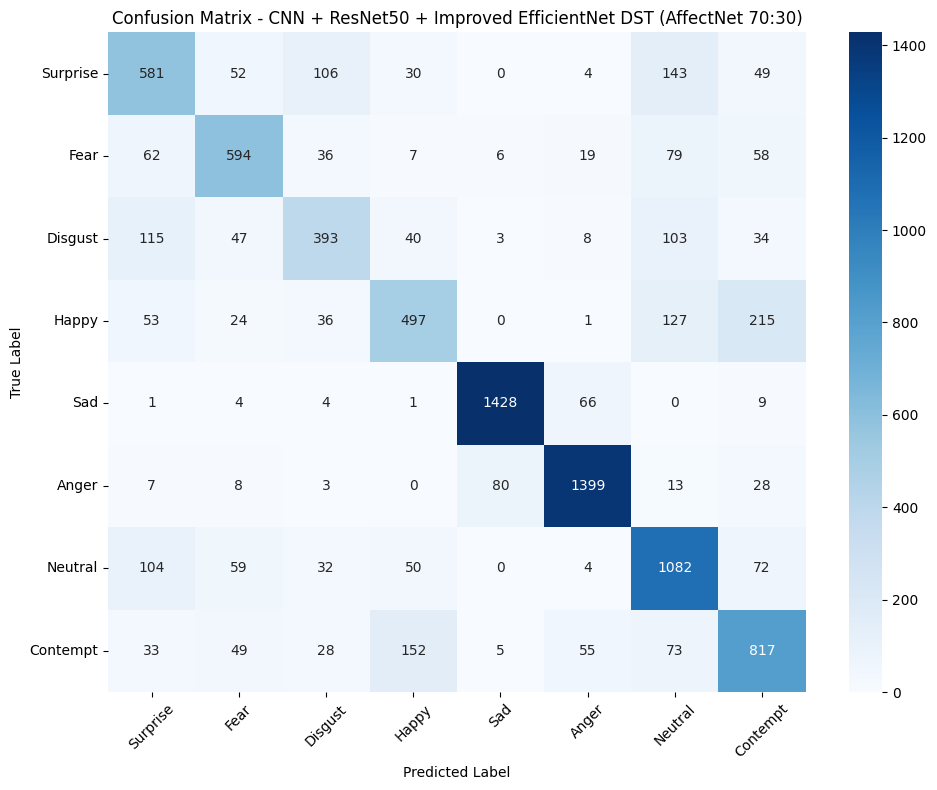

Classification Report - CNN + ResNet50 + Improved EfficientNet DST (AffectNet 70:30)


,precision,recall,f1-score,support
Surprise,0.607741,0.602073,0.604893,965.000000
Fear,0.709677,0.689895,0.699647,861.000000
Disgust,0.615987,0.528937,0.569153,743.000000
Happy,0.639640,0.521511,0.574566,953.000000
Sad,0.938239,0.943820,0.941021,1513.000000
Anger,0.899100,0.909623,0.904331,1538.000000
Neutral,0.667901,0.771205,0.715845,1403.000000
Contempt,0.637285,0.674092,0.655172,1212.000000
accuracy,0.739116,0.739116,0.739116,0.739116
macro avg,0.714446,0.705144,0.708079,9188.000000


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# =========================================================
# True labels and best fusion predictions
# =========================================================
y_true_best_fusion_70_30 = y_true_fusion_affect_70_30
y_pred_best_fusion_70_30 = cnn_resnet_eff_preds_70_30   # best 70:30 fusion

# =========================================================
# Confusion Matrix
# =========================================================
cm_best_fusion_70_30 = confusion_matrix(
    y_true_best_fusion_70_30,
    y_pred_best_fusion_70_30
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_best_fusion_70_30,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_affect,
    yticklabels=class_names_affect
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - CNN + ResNet50 + Improved EfficientNet DST (AffectNet 70:30)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================================================
# Classification Report
# =========================================================
report_best_fusion_70_30 = classification_report(
    y_true_best_fusion_70_30,
    y_pred_best_fusion_70_30,
    target_names=class_names_affect,
    output_dict=True
)

report_df_best_fusion_70_30 = pd.DataFrame(report_best_fusion_70_30).transpose()

print("Classification Report - CNN + ResNet50 + Improved EfficientNet DST (AffectNet 70:30)")
display(report_df_best_fusion_70_30)

In [33]:
from sklearn.metrics import classification_report

# =========================================================
# Best 70:30 fusion predictions
# =========================================================
y_true_best_fusion_70_30 = y_true_fusion_affect_70_30
y_pred_best_fusion_70_30 = cnn_resnet_eff_preds_70_30   # best 70:30 fusion

# =========================================================
# Class names in the same order as your label mapping
# =========================================================
class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# Classification report in clean text format
# =========================================================
report_text_70_30 = classification_report(
    y_true_best_fusion_70_30,
    y_pred_best_fusion_70_30,
    target_names=class_names_affect
)

print("Classification Report - CustomCNN + ResNet50 + Improved EfficientNet DST")
print(report_text_70_30)

Classification Report - CustomCNN + ResNet50 + Improved EfficientNet DST
              precision    recall  f1-score   support

       Anger       0.61      0.60      0.60       965
    Contempt       0.71      0.69      0.70       861
     Disgust       0.62      0.53      0.57       743
        Fear       0.64      0.52      0.57       953
       Happy       0.94      0.94      0.94      1513
     Neutral       0.90      0.91      0.90      1538
         Sad       0.67      0.77      0.72      1403
    Surprise       0.64      0.67      0.66      1212

    accuracy                           0.74      9188
   macro avg       0.71      0.71      0.71      9188
weighted avg       0.74      0.74      0.74      9188



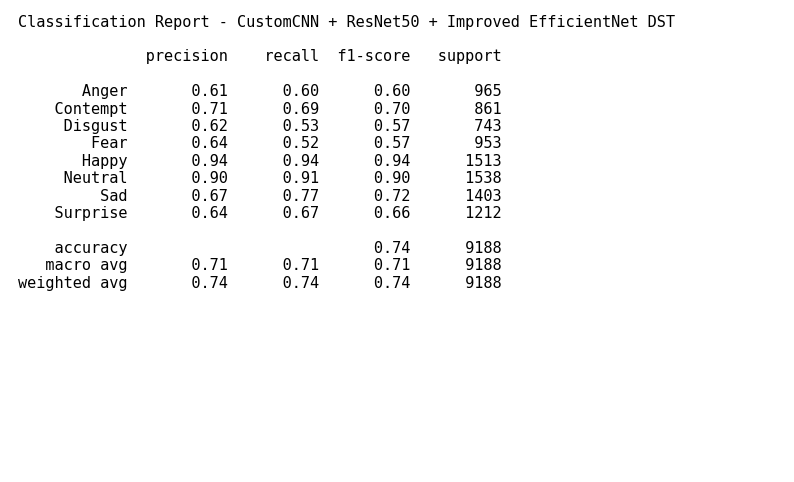

Saved classification report image: /kaggle/working/classification_report_best_fusion_70_30.png


In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.axis('off')
plt.text(
    0.01, 0.99,
    "Classification Report - CustomCNN + ResNet50 + Improved EfficientNet DST\n\n" + report_text_70_30,
    fontsize=11,
    family='monospace',
    va='top'
)

report_img_path_70_30 = "/kaggle/working/classification_report_best_fusion_70_30.png"
plt.savefig(report_img_path_70_30, bbox_inches='tight', dpi=300)
plt.show()

print("Saved classification report image:", report_img_path_70_30)

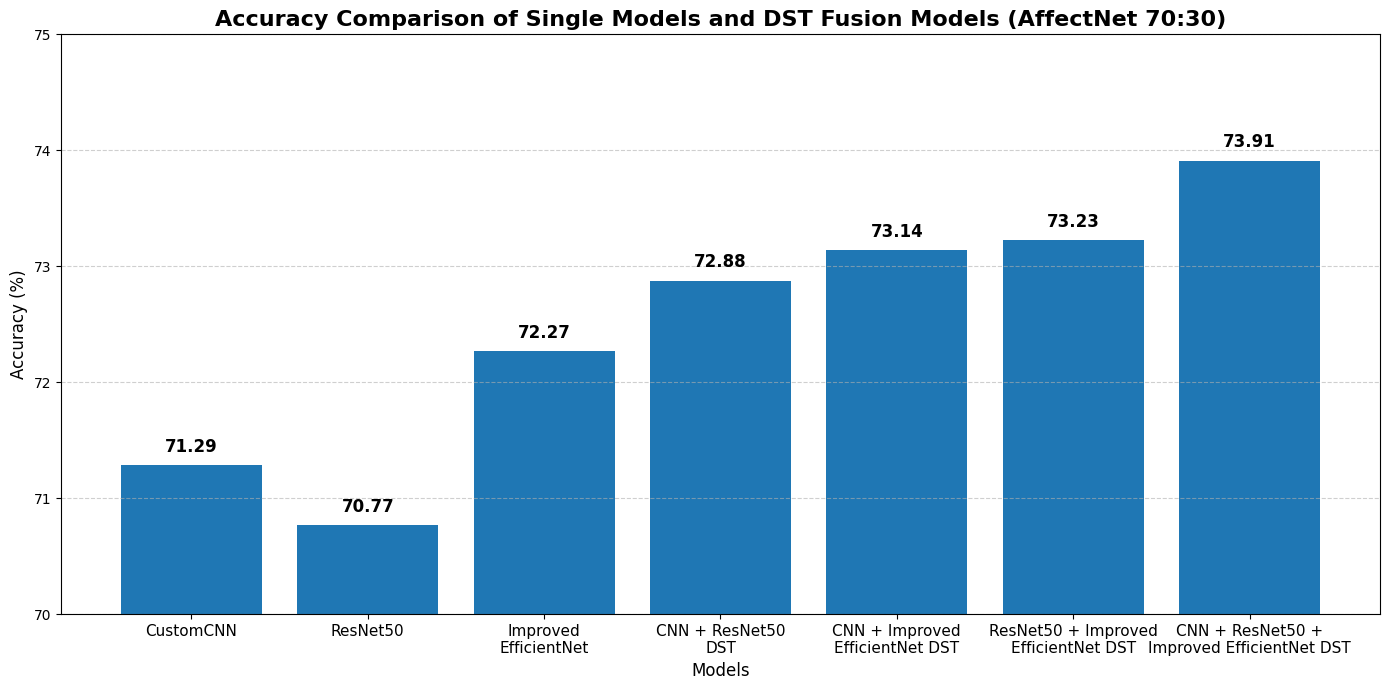

Saved chart: /kaggle/working/accuracy_comparison_70_30_AffectNet.png


In [35]:
import matplotlib.pyplot as plt

# =========================================================
# Model names and 70:30 accuracies
# =========================================================
models_70_30 = [
    "CustomCNN",
    "ResNet50",
    "Improved\nEfficientNet",
    "CNN + ResNet50\nDST",
    "CNN + Improved\nEfficientNet DST",
    "ResNet50 + Improved\nEfficientNet DST",
    "CNN + ResNet50 +\nImproved EfficientNet DST"
]

accuracies_70_30 = [
    cnn_acc_affect_70_30,          # 71.29
    resnet_acc_affect_70_30,       # 70.77
    eff_acc_affect_70_30,          # 72.27
    cnn_resnet_acc_70_30,          # 72.88
    cnn_eff_acc_70_30,             # 73.14
    resnet_eff_acc_70_30,          # 73.23
    cnn_resnet_eff_acc_70_30       # 73.91
]

# =========================================================
# Plot
# =========================================================
plt.figure(figsize=(14, 7))
bars = plt.bar(models_70_30, accuracies_70_30)

plt.title("Accuracy Comparison of Single Models and DST Fusion Models (AffectNet 70:30)", fontsize=16, fontweight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(70, 75)   # you can change to (70, 76) if you want more space
plt.grid(axis='y', linestyle='--', alpha=0.6)

# add accuracy values on top
for bar, acc in zip(bars, accuracies_70_30):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.08,
        f"{acc:.2f}",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.xticks(rotation=0, fontsize=11)
plt.tight_layout()

# =========================================================
# Save figure
# =========================================================
chart_path_70_30 = "/kaggle/working/accuracy_comparison_70_30_AffectNet.png"
plt.savefig(chart_path_70_30, dpi=300, bbox_inches="tight")
plt.show()

print("Saved chart:", chart_path_70_30)

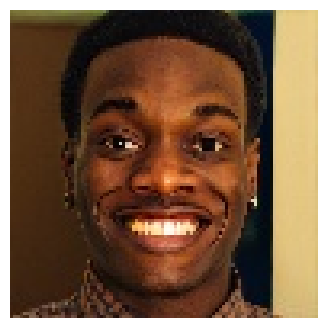

Random Test Image Path: /kaggle/input/datasets/mstjebashazida/affectnet/archive (3)/Train/surprise/image0033219.jpg
True Label: 7 - Surprise

CNN input shape               : torch.Size([1, 3, 96, 96])
ResNet50 input shape          : torch.Size([1, 3, 96, 96])
Improved EfficientNet shape   : torch.Size([1, 3, 224, 224])

CNN probabilities shape              : (8,)
ResNet50 probabilities shape         : (8,)
Improved EfficientNet probabilities  : (8,)

CNN Prediction                         : Surprise
ResNet50 Prediction                    : Surprise
Improved EfficientNet Prediction       : Surprise
CNN + ResNet50 DST Prediction          : Surprise
CNN + EfficientNet DST Prediction      : Surprise
ResNet50 + EfficientNet DST Prediction : Surprise
CNN + ResNet50 + EfficientNet Prediction : Surprise

Full Probability Table for Selected Image:


,Emotion,CNN,ResNet50,EfficientNet,CNN+ResNet DST,CNN+EffNet DST,ResNet+EffNet DST,CNN+ResNet+EffNet DST
0,Anger,0.025730,0.002849,0.002702,0.002831,0.002800,0.000324,0.000192
1,Contempt,0.205887,0.018114,0.040274,0.027850,0.037986,0.004112,0.003140
2,Disgust,0.037830,0.005833,0.006883,0.004520,0.004673,0.000767,0.000342
3,Fear,0.123049,0.036536,0.029599,0.023141,0.020874,0.004933,0.002309
4,Happy,0.073689,0.027427,0.013305,0.013178,0.009938,0.002713,0.001053
5,Neutral,0.003781,0.004146,0.003000,0.000777,0.000658,0.000420,0.000065
6,Sad,0.044444,0.001954,0.002301,0.004538,0.004581,0.000247,0.000294
7,Surprise,0.485591,0.903141,0.901936,0.918194,0.913538,0.983489,0.992311


In [40]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

# =========================================================
# Class names in AffectNet label order
# IMPORTANT: keep this same as your label encoding
# =========================================================
class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# Pick one random test image from AffectNet 70:30
# =========================================================
random_idx_70_30 = random.randint(0, len(test_df_affect_70_30) - 1)
random_row_70_30 = test_df_affect_70_30.iloc[random_idx_70_30]

random_image_path_70_30 = random_row_70_30["image_path"]
random_true_label_70_30 = random_row_70_30["label"]

# =========================================================
# Load image
# =========================================================
pil_img_70_30 = Image.open(random_image_path_70_30).convert("RGB")

# show image first
plt.figure(figsize=(4,4))
plt.imshow(pil_img_70_30)
plt.axis("off")
plt.show()

print("Random Test Image Path:", random_image_path_70_30)
print("True Label:", random_true_label_70_30, "-", class_names_affect[random_true_label_70_30])

# =========================================================
# Prepare model inputs
# =========================================================
cnn_input_70_30 = resnet_test_transform_affect_70_30(pil_img_70_30).unsqueeze(0).to(device)
eff_input_70_30 = eff_test_transform_affect_70_30(pil_img_70_30).unsqueeze(0).to(device)

print("\nCNN input shape               :", cnn_input_70_30.shape)
print("ResNet50 input shape          :", cnn_input_70_30.shape)
print("Improved EfficientNet shape   :", eff_input_70_30.shape)

# =========================================================
# Put models in eval mode
# =========================================================
cnn_model_affect_70_30.eval()
resnet_model_affect_70_30.eval()
efficientnet_model_affect_70_30.eval()

# =========================================================
# Get probabilities from all 3 models
# =========================================================
with torch.no_grad():
    # CNN
    cnn_logits_single_70_30 = cnn_model_affect_70_30(cnn_input_70_30)
    cnn_probs_single_70_30 = F.softmax(cnn_logits_single_70_30, dim=1).cpu().numpy()[0]

    # ResNet50
    resnet_logits_single_70_30 = resnet_model_affect_70_30(cnn_input_70_30)
    resnet_probs_single_70_30 = F.softmax(resnet_logits_single_70_30, dim=1).cpu().numpy()[0]

    # EfficientNet
    eff_logits_single_70_30 = efficientnet_model_affect_70_30(eff_input_70_30)
    eff_probs_single_70_30 = F.softmax(eff_logits_single_70_30, dim=1).cpu().numpy()[0]

print("\nCNN probabilities shape              :", cnn_probs_single_70_30.shape)
print("ResNet50 probabilities shape         :", resnet_probs_single_70_30.shape)
print("Improved EfficientNet probabilities  :", eff_probs_single_70_30.shape)

# =========================================================
# Convert to DST masses
# =========================================================
m_cnn_70_30 = probs_to_mass(cnn_probs_single_70_30)
m_resnet_70_30 = probs_to_mass(resnet_probs_single_70_30)
m_eff_70_30 = probs_to_mass(eff_probs_single_70_30)

# =========================================================
# DST fusion outputs
# =========================================================
cnn_resnet_dst_70_30 = dst_combine_two(m_cnn_70_30, m_resnet_70_30)
cnn_eff_dst_70_30 = dst_combine_two(m_cnn_70_30, m_eff_70_30)
resnet_eff_dst_70_30 = dst_combine_two(m_resnet_70_30, m_eff_70_30)
cnn_resnet_eff_dst_70_30 = dst_combine_three(m_cnn_70_30, m_resnet_70_30, m_eff_70_30)

# remove uncertainty part
cnn_resnet_dst_probs_70_30 = cnn_resnet_dst_70_30[:-1]
cnn_eff_dst_probs_70_30 = cnn_eff_dst_70_30[:-1]
resnet_eff_dst_probs_70_30 = resnet_eff_dst_70_30[:-1]
cnn_resnet_eff_dst_probs_70_30 = cnn_resnet_eff_dst_70_30[:-1]

# =========================================================
# Predictions
# =========================================================
cnn_pred_70_30 = np.argmax(cnn_probs_single_70_30)
resnet_pred_70_30 = np.argmax(resnet_probs_single_70_30)
eff_pred_70_30 = np.argmax(eff_probs_single_70_30)

cnn_resnet_pred_70_30 = np.argmax(cnn_resnet_dst_probs_70_30)
cnn_eff_pred_70_30 = np.argmax(cnn_eff_dst_probs_70_30)
resnet_eff_pred_70_30 = np.argmax(resnet_eff_dst_probs_70_30)
cnn_resnet_eff_pred_70_30 = np.argmax(cnn_resnet_eff_dst_probs_70_30)

# =========================================================
# Print predictions
# =========================================================
print("\nCNN Prediction                         :", class_names_affect[cnn_pred_70_30])
print("ResNet50 Prediction                    :", class_names_affect[resnet_pred_70_30])
print("Improved EfficientNet Prediction       :", class_names_affect[eff_pred_70_30])
print("CNN + ResNet50 DST Prediction          :", class_names_affect[cnn_resnet_pred_70_30])
print("CNN + EfficientNet DST Prediction      :", class_names_affect[cnn_eff_pred_70_30])
print("ResNet50 + EfficientNet DST Prediction :", class_names_affect[resnet_eff_pred_70_30])
print("CNN + ResNet50 + EfficientNet Prediction :", class_names_affect[cnn_resnet_eff_pred_70_30])

# =========================================================
# Full probability table
# =========================================================
prob_table_70_30 = pd.DataFrame({
    "Emotion": class_names_affect,
    "CNN": cnn_probs_single_70_30,
    "ResNet50": resnet_probs_single_70_30,
    "EfficientNet": eff_probs_single_70_30,
    "CNN+ResNet DST": cnn_resnet_dst_probs_70_30,
    "CNN+EffNet DST": cnn_eff_dst_probs_70_30,
    "ResNet+EffNet DST": resnet_eff_dst_probs_70_30,
    "CNN+ResNet+EffNet DST": cnn_resnet_eff_dst_probs_70_30
})

print("\nFull Probability Table for Selected Image:")
display(prob_table_70_30)

In [ ]:
/kaggle/input/datasets/ankan980/suprise-face/surprise_img.jpeg

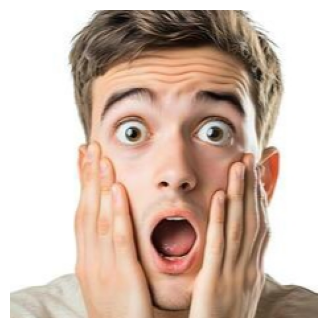

Uploaded Image Path: /kaggle/input/datasets/ankan980/suprise-face/surprise_img.jpeg

CNN input shape               : torch.Size([1, 3, 96, 96])
ResNet50 input shape          : torch.Size([1, 3, 96, 96])
Improved EfficientNet shape   : torch.Size([1, 3, 224, 224])

CNN probabilities shape              : (8,)
ResNet50 probabilities shape         : (8,)
Improved EfficientNet probabilities  : (8,)

CNN Prediction                         : Surprise
ResNet50 Prediction                    : Fear
Improved EfficientNet Prediction       : Fear
CNN + ResNet50 DST Prediction          : Fear
CNN + EfficientNet DST Prediction      : Surprise
ResNet50 + EfficientNet DST Prediction : Fear
CNN + ResNet50 + EfficientNet Prediction : Fear

Full Probability Table for Uploaded Image:


,Emotion,CNN,ResNet50,EfficientNet,CNN+ResNet DST,CNN+EffNet DST,ResNet+EffNet DST,CNN+ResNet+EffNet DST
0,Anger,0.000455,0.008158,0.019189,0.000839,0.001824,0.002688,0.000284
1,Contempt,0.000092,0.004800,0.010513,0.000474,0.000978,0.001442,0.000150
2,Disgust,0.000203,0.002422,0.009113,0.000255,0.000861,0.001060,0.000112
3,Fear,0.451211,0.906844,0.511660,0.882544,0.492538,0.907228,0.901606
4,Happy,0.000101,0.008312,0.007957,0.000815,0.000743,0.001554,0.000162
5,Neutral,0.000068,0.007998,0.011254,0.000780,0.001044,0.001858,0.000193
6,Sad,0.000179,0.011430,0.005431,0.001126,0.000518,0.001599,0.000167
7,Surprise,0.547692,0.050037,0.424883,0.108082,0.496648,0.077906,0.096843


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

# =========================================================
# 1) CLASS NAMES
# IMPORTANT: keep same order as your AffectNet label encoding
# =========================================================
class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# 2) GIVE YOUR UPLOADED IMAGE PATH HERE
# Example:
# uploaded_image_path = "/kaggle/working/my_photo.jpg"
# =========================================================
uploaded_image_path = "/kaggle/input/datasets/ankan980/suprise-face/surprise_img.jpeg"   # <-- CHANGE THIS

# =========================================================
# 3) LOAD IMAGE
# =========================================================
pil_img = Image.open(uploaded_image_path).convert("RGB")

# show image
plt.figure(figsize=(4,4))
plt.imshow(pil_img)
plt.axis("off")
plt.show()

print("Uploaded Image Path:", uploaded_image_path)

# =========================================================
# 4) PREPARE INPUTS
# CNN / ResNet -> 96x96
# EfficientNet -> 224x224
# =========================================================
cnn_input = resnet_test_transform_affect_70_30(pil_img).unsqueeze(0).to(device)
eff_input = eff_test_transform_affect_70_30(pil_img).unsqueeze(0).to(device)

print("\nCNN input shape               :", cnn_input.shape)
print("ResNet50 input shape          :", cnn_input.shape)
print("Improved EfficientNet shape   :", eff_input.shape)

# =========================================================
# 5) LOAD MODELS IN EVAL MODE
# =========================================================
cnn_model_affect_70_30.eval()
resnet_model_affect_70_30.eval()
efficientnet_model_affect_70_30.eval()

# =========================================================
# 6) GET SOFTMAX PROBABILITIES
# =========================================================
with torch.no_grad():
    # CNN
    cnn_logits = cnn_model_affect_70_30(cnn_input)
    cnn_probs = F.softmax(cnn_logits, dim=1).cpu().numpy()[0]

    # ResNet50
    resnet_logits = resnet_model_affect_70_30(cnn_input)
    resnet_probs = F.softmax(resnet_logits, dim=1).cpu().numpy()[0]

    # EfficientNet
    eff_logits = efficientnet_model_affect_70_30(eff_input)
    eff_probs = F.softmax(eff_logits, dim=1).cpu().numpy()[0]

print("\nCNN probabilities shape              :", cnn_probs.shape)
print("ResNet50 probabilities shape         :", resnet_probs.shape)
print("Improved EfficientNet probabilities  :", eff_probs.shape)

# =========================================================
# 7) DST FUSION
# =========================================================
m_cnn = probs_to_mass(cnn_probs)
m_resnet = probs_to_mass(resnet_probs)
m_eff = probs_to_mass(eff_probs)

cnn_resnet_dst = dst_combine_two(m_cnn, m_resnet)
cnn_eff_dst = dst_combine_two(m_cnn, m_eff)
resnet_eff_dst = dst_combine_two(m_resnet, m_eff)
cnn_resnet_eff_dst = dst_combine_three(m_cnn, m_resnet, m_eff)

# remove uncertainty mass
cnn_resnet_dst_probs = cnn_resnet_dst[:-1]
cnn_eff_dst_probs = cnn_eff_dst[:-1]
resnet_eff_dst_probs = resnet_eff_dst[:-1]
cnn_resnet_eff_dst_probs = cnn_resnet_eff_dst[:-1]

# =========================================================
# 8) PREDICTIONS
# =========================================================
cnn_pred = np.argmax(cnn_probs)
resnet_pred = np.argmax(resnet_probs)
eff_pred = np.argmax(eff_probs)

cnn_resnet_pred = np.argmax(cnn_resnet_dst_probs)
cnn_eff_pred = np.argmax(cnn_eff_dst_probs)
resnet_eff_pred = np.argmax(resnet_eff_dst_probs)
cnn_resnet_eff_pred = np.argmax(cnn_resnet_eff_dst_probs)

# =========================================================
# 9) PRINT PREDICTIONS
# =========================================================
print("\nCNN Prediction                         :", class_names_affect[cnn_pred])
print("ResNet50 Prediction                    :", class_names_affect[resnet_pred])
print("Improved EfficientNet Prediction       :", class_names_affect[eff_pred])
print("CNN + ResNet50 DST Prediction          :", class_names_affect[cnn_resnet_pred])
print("CNN + EfficientNet DST Prediction      :", class_names_affect[cnn_eff_pred])
print("ResNet50 + EfficientNet DST Prediction :", class_names_affect[resnet_eff_pred])
print("CNN + ResNet50 + EfficientNet Prediction :", class_names_affect[cnn_resnet_eff_pred])

# =========================================================
# 10) FULL PROBABILITY TABLE
# =========================================================
prob_table_uploaded = pd.DataFrame({
    "Emotion": class_names_affect,
    "CNN": cnn_probs,
    "ResNet50": resnet_probs,
    "EfficientNet": eff_probs,
    "CNN+ResNet DST": cnn_resnet_dst_probs,
    "CNN+EffNet DST": cnn_eff_dst_probs,
    "ResNet+EffNet DST": resnet_eff_dst_probs,
    "CNN+ResNet+EffNet DST": cnn_resnet_eff_dst_probs
})

print("\nFull Probability Table for Uploaded Image:")
display(prob_table_uploaded)

In [ ]:
/kaggle/input/datasets/ankan980/sad-img/sad_image.jpeg

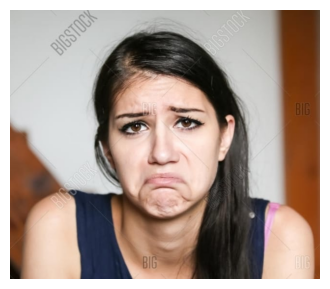

Uploaded Image Path: /kaggle/input/datasets/ankan980/sad-img/sad_image.jpeg

CNN input shape               : torch.Size([1, 3, 96, 96])
ResNet50 input shape          : torch.Size([1, 3, 96, 96])
Improved EfficientNet shape   : torch.Size([1, 3, 224, 224])

CNN probabilities shape              : (8,)
ResNet50 probabilities shape         : (8,)
Improved EfficientNet probabilities  : (8,)

CNN Prediction                         : Sad
ResNet50 Prediction                    : Fear
Improved EfficientNet Prediction       : Sad
CNN + ResNet50 DST Prediction          : Fear
CNN + EfficientNet DST Prediction      : Sad
ResNet50 + EfficientNet DST Prediction : Sad
CNN + ResNet50 + EfficientNet Prediction : Sad

Full Probability Table for Uploaded Image:


,Emotion,CNN,ResNet50,EfficientNet,CNN+ResNet DST,CNN+EffNet DST,ResNet+EffNet DST,CNN+ResNet+EffNet DST
0,Anger,0.243914,0.126544,0.154884,0.187652,0.162059,0.123454,0.130324
1,Contempt,0.056028,0.027351,0.018833,0.022061,0.013775,0.010568,0.005693
2,Disgust,0.088268,0.038911,0.048414,0.037737,0.031622,0.023247,0.013865
3,Fear,0.116178,0.450775,0.051178,0.306309,0.040686,0.177543,0.103920
4,Happy,0.023870,0.007552,0.007199,0.006834,0.004983,0.002980,0.001553
5,Neutral,0.054466,0.027161,0.012965,0.021519,0.011734,0.008840,0.004968
6,Sad,0.299929,0.179325,0.666875,0.294381,0.691884,0.588805,0.703037
7,Surprise,0.117346,0.142380,0.039651,0.113185,0.035617,0.054625,0.034894


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

# =========================================================
# 1) CLASS NAMES
# IMPORTANT: keep same order as your AffectNet label encoding
# =========================================================
class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# 2) GIVE YOUR UPLOADED IMAGE PATH HERE
# Example:
# uploaded_image_path = "/kaggle/working/my_photo.jpg"
# =========================================================
uploaded_image_path = "/kaggle/input/datasets/ankan980/sad-img/sad_image.jpeg"   

# =========================================================
# 3) LOAD IMAGE
# =========================================================
pil_img = Image.open(uploaded_image_path).convert("RGB")

# show image
plt.figure(figsize=(4,4))
plt.imshow(pil_img)
plt.axis("off")
plt.show()

print("Uploaded Image Path:", uploaded_image_path)

# =========================================================
# 4) PREPARE INPUTS
# CNN / ResNet -> 96x96
# EfficientNet -> 224x224
# =========================================================
cnn_input = resnet_test_transform_affect_70_30(pil_img).unsqueeze(0).to(device)
eff_input = eff_test_transform_affect_70_30(pil_img).unsqueeze(0).to(device)

print("\nCNN input shape               :", cnn_input.shape)
print("ResNet50 input shape          :", cnn_input.shape)
print("Improved EfficientNet shape   :", eff_input.shape)

# =========================================================
# 5) LOAD MODELS IN EVAL MODE
# =========================================================
cnn_model_affect_70_30.eval()
resnet_model_affect_70_30.eval()
efficientnet_model_affect_70_30.eval()

# =========================================================
# 6) GET SOFTMAX PROBABILITIES
# =========================================================
with torch.no_grad():
    # CNN
    cnn_logits = cnn_model_affect_70_30(cnn_input)
    cnn_probs = F.softmax(cnn_logits, dim=1).cpu().numpy()[0]

    # ResNet50
    resnet_logits = resnet_model_affect_70_30(cnn_input)
    resnet_probs = F.softmax(resnet_logits, dim=1).cpu().numpy()[0]

    # EfficientNet
    eff_logits = efficientnet_model_affect_70_30(eff_input)
    eff_probs = F.softmax(eff_logits, dim=1).cpu().numpy()[0]

print("\nCNN probabilities shape              :", cnn_probs.shape)
print("ResNet50 probabilities shape         :", resnet_probs.shape)
print("Improved EfficientNet probabilities  :", eff_probs.shape)

# =========================================================
# 7) DST FUSION
# =========================================================
m_cnn = probs_to_mass(cnn_probs)
m_resnet = probs_to_mass(resnet_probs)
m_eff = probs_to_mass(eff_probs)

cnn_resnet_dst = dst_combine_two(m_cnn, m_resnet)
cnn_eff_dst = dst_combine_two(m_cnn, m_eff)
resnet_eff_dst = dst_combine_two(m_resnet, m_eff)
cnn_resnet_eff_dst = dst_combine_three(m_cnn, m_resnet, m_eff)

# remove uncertainty mass
cnn_resnet_dst_probs = cnn_resnet_dst[:-1]
cnn_eff_dst_probs = cnn_eff_dst[:-1]
resnet_eff_dst_probs = resnet_eff_dst[:-1]
cnn_resnet_eff_dst_probs = cnn_resnet_eff_dst[:-1]

# =========================================================
# 8) PREDICTIONS
# =========================================================
cnn_pred = np.argmax(cnn_probs)
resnet_pred = np.argmax(resnet_probs)
eff_pred = np.argmax(eff_probs)

cnn_resnet_pred = np.argmax(cnn_resnet_dst_probs)
cnn_eff_pred = np.argmax(cnn_eff_dst_probs)
resnet_eff_pred = np.argmax(resnet_eff_dst_probs)
cnn_resnet_eff_pred = np.argmax(cnn_resnet_eff_dst_probs)

# =========================================================
# 9) PRINT PREDICTIONS
# =========================================================
print("\nCNN Prediction                         :", class_names_affect[cnn_pred])
print("ResNet50 Prediction                    :", class_names_affect[resnet_pred])
print("Improved EfficientNet Prediction       :", class_names_affect[eff_pred])
print("CNN + ResNet50 DST Prediction          :", class_names_affect[cnn_resnet_pred])
print("CNN + EfficientNet DST Prediction      :", class_names_affect[cnn_eff_pred])
print("ResNet50 + EfficientNet DST Prediction :", class_names_affect[resnet_eff_pred])
print("CNN + ResNet50 + EfficientNet Prediction :", class_names_affect[cnn_resnet_eff_pred])

# =========================================================
# 10) FULL PROBABILITY TABLE
# =========================================================
prob_table_uploaded = pd.DataFrame({
    "Emotion": class_names_affect,
    "CNN": cnn_probs,
    "ResNet50": resnet_probs,
    "EfficientNet": eff_probs,
    "CNN+ResNet DST": cnn_resnet_dst_probs,
    "CNN+EffNet DST": cnn_eff_dst_probs,
    "ResNet+EffNet DST": resnet_eff_dst_probs,
    "CNN+ResNet+EffNet DST": cnn_resnet_eff_dst_probs
})

print("\nFull Probability Table for Uploaded Image:")
display(prob_table_uploaded)

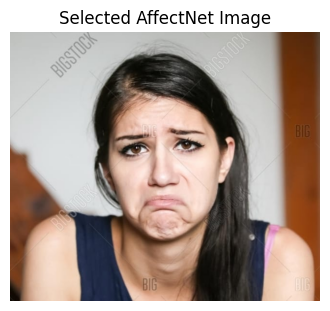

,Emotion,CNN,ResNet50,EfficientNet,DST Fusion
0,Anger,0.243914,0.126544,0.154884,0.130324
1,Contempt,0.056028,0.027351,0.018833,0.005693
2,Disgust,0.088268,0.038911,0.048414,0.013865
3,Fear,0.116178,0.450775,0.051178,0.103920
4,Happy,0.023870,0.007552,0.007199,0.001553
5,Neutral,0.054466,0.027161,0.012965,0.004968
6,Sad,0.299929,0.179325,0.666875,0.703037
7,Surprise,0.117346,0.142380,0.039651,0.034894



CNN Prediction      : Sad
ResNet50 Prediction : Fear
EfficientNet Prediction : Sad
DST Prediction      : Sad


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn.functional as F

# =========================================================
# 1) Class names in your AffectNet label order
# IMPORTANT: keep this same as your label encoding
# =========================================================
class_names_affect = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# =========================================================
# 2) Put your uploaded image path here
# Example:
# uploaded_image_path = "/kaggle/working/my_uploaded_image.jpg"
# =========================================================
uploaded_image_path = "/kaggle/input/datasets/ankan980/sad-img/sad_image.jpeg"   

# =========================================================
# 3) Load image
# =========================================================
pil_img = Image.open(uploaded_image_path).convert("RGB")

# =========================================================
# 4) Show image like your sample format
# =========================================================
plt.figure(figsize=(4,4))
plt.imshow(pil_img)
plt.axis("off")
plt.title("Selected AffectNet Image")
plt.show()

# =========================================================
# 5) Prepare inputs
# CNN / ResNet -> 96x96
# EfficientNet -> 224x224
# =========================================================
cnn_input = resnet_test_transform_affect_70_30(pil_img).unsqueeze(0).to(device)
eff_input = eff_test_transform_affect_70_30(pil_img).unsqueeze(0).to(device)

# =========================================================
# 6) Eval mode
# =========================================================
cnn_model_affect_70_30.eval()
resnet_model_affect_70_30.eval()
efficientnet_model_affect_70_30.eval()

# =========================================================
# 7) Get softmax probabilities
# =========================================================
with torch.no_grad():
    cnn_logits = cnn_model_affect_70_30(cnn_input)
    cnn_probs = F.softmax(cnn_logits, dim=1).cpu().numpy()[0]

    resnet_logits = resnet_model_affect_70_30(cnn_input)
    resnet_probs = F.softmax(resnet_logits, dim=1).cpu().numpy()[0]

    eff_logits = efficientnet_model_affect_70_30(eff_input)
    eff_probs = F.softmax(eff_logits, dim=1).cpu().numpy()[0]

# =========================================================
# 8) DST fusion
# =========================================================
m_cnn = probs_to_mass(cnn_probs)
m_resnet = probs_to_mass(resnet_probs)
m_eff = probs_to_mass(eff_probs)

dst_fusion = dst_combine_three(m_cnn, m_resnet, m_eff)
dst_probs = dst_fusion[:-1]   # remove uncertainty mass

# =========================================================
# 9) Predictions
# =========================================================
cnn_pred = np.argmax(cnn_probs)
resnet_pred = np.argmax(resnet_probs)
eff_pred = np.argmax(eff_probs)
dst_pred = np.argmax(dst_probs)

# =========================================================
# 10) Make probability table in the same compact format
# =========================================================
prob_table = pd.DataFrame({
    "Emotion": class_names_affect,
    "CNN": cnn_probs,
    "ResNet50": resnet_probs,
    "EfficientNet": eff_probs,
    "DST Fusion": dst_probs
})

# round for cleaner display
prob_table_display = prob_table.copy()
for col in prob_table_display.columns[1:]:
    prob_table_display[col] = prob_table_display[col].map(lambda x: f"{x:.6f}")

display(prob_table_display)

# =========================================================
# 11) Print predictions exactly like your sample
# =========================================================
print("\nCNN Prediction      :", class_names_affect[cnn_pred])
print("ResNet50 Prediction :", class_names_affect[resnet_pred])
print("EfficientNet Prediction :", class_names_affect[eff_pred])
print("DST Prediction      :", class_names_affect[dst_pred])

In [48]:
import pandas as pd

# =========================================================
# Final summary table for AffectNet 70:30
# =========================================================
summary_table_affect_70_30 = pd.DataFrame({
    "Category": [
        "DST Fusion",
        "DST Fusion",
        "DST Fusion",
        "DST Fusion",
        "Single Model",
        "Single Model",
        "Single Model"
    ],
    "Model": [
        "CustomCNN + ResNet50 + Improved EfficientNet",
        "ResNet50 + Improved EfficientNet",
        "CustomCNN + Improved EfficientNet",
        "CustomCNN + ResNet50",
        "Improved EfficientNet",
        "CustomCNN",
        "ResNet50"
    ],
    "Accuracy (%)": [
        cnn_resnet_eff_acc_70_30,   # 73.91
        resnet_eff_acc_70_30,       # 73.23
        cnn_eff_acc_70_30,          # 73.14
        cnn_resnet_acc_70_30,       # 72.88
        eff_acc_affect_70_30,       # 72.27
        cnn_acc_affect_70_30,       # 71.29
        resnet_acc_affect_70_30     # 70.77
    ]
})

# sort descending by accuracy
summary_table_affect_70_30 = summary_table_affect_70_30.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

print("Final AffectNet 70:30 Summary Table:\n")
display(summary_table_affect_70_30)

# =========================================================
# Best final model
# =========================================================
best_row_70_30 = summary_table_affect_70_30.iloc[0]

print("\nBest Final Model on AffectNet 70:30:")
print(f"{best_row_70_30['Model']} --> {best_row_70_30['Accuracy (%)']:.2f}% accuracy")

Final AffectNet 70:30 Summary Table:



,Category,Model,Accuracy (%)
0,DST Fusion,CustomCNN + ResNet50 + Improved EfficientNet,73.911624
1,DST Fusion,ResNet50 + Improved EfficientNet,73.225947
2,DST Fusion,CustomCNN + Improved EfficientNet,73.138877
3,DST Fusion,CustomCNN + ResNet50,72.877667
4,Single Model,Improved EfficientNet,72.268176
5,Single Model,CustomCNN,71.288637
6,Single Model,ResNet50,70.766217



Best Final Model on AffectNet 70:30:
CustomCNN + ResNet50 + Improved EfficientNet --> 73.91% accuracy


In [49]:
summary_table_affect_70_30.to_csv("/kaggle/working/final_affectnet_70_30_summary.csv", index=False)